In [18]:
import os 
from langchain_openai import ChatOpenAI
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, END
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

from dotenv import load_dotenv

In [19]:
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [20]:
class State(TypedDict):
    text : str
    classification : str
    entity : list[str]
    summary : str 

llm = ChatOpenAI(model = "gpt-4.1-mini", temperature= 0)

In [21]:
def classification_node(state:State):
    prompt = PromptTemplate(
        input_variable = ['text'],
        template = "Classify the following text provided by the user and classify the text in to following categories: Billing, Technical, General.\n\nText:{text}\n\nCategory:"
    )
    message = HumanMessage(content = prompt.format(text = state['text']))
    classification  = llm.invoke([message]).content.strip()
    return {'classification':classification}

def entity_recognition_mode(state:State):
    entity_prompt = PromptTemplate(
        input_variable = ['text'],
        template = "Understand the user's entity from the following text and extract the entity. The entity can be a Response, Troubleshoot, or FAQ mentioned in the text.\n\nText:{text}\n\nEntity:"
    )
    message = HumanMessage(content = entity_prompt.format(text = state['text']))
    entity = llm.invoke([message]).content.strip()
    entity_list = [e.strip() for e in entity.split(',')]
    return {'entity':entity_list}

def summarization_node(state:State):
    summary_prompt = PromptTemplate(
        input_variable = ['text'],
        template = "Summarize the following text provided by the user in one or two sentences.\n\nText:{text}\n\nSummary:"
    )
    message = HumanMessage(content = summary_prompt.format(text = state['text']))
    summary = llm.invoke([message]).content.strip()
    return {'summary':summary}      

In [22]:
workflow = StateGraph(State)
workflow.add_node("classification_node",classification_node)
workflow.add_node("entity_recognition_node", entity_recognition_mode)
workflow.add_node("summarization_node", summarization_node)

workflow.set_entry_point("classification_node")
workflow.add_edge("classification_node","entity_recognition_node")
workflow.add_edge("entity_recognition_node","summarization_node")
workflow.add_edge("summarization_node",END)

app = workflow.compile()


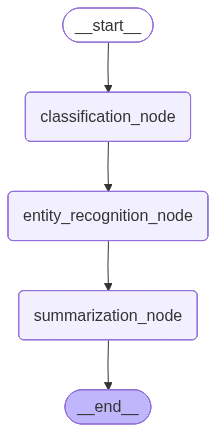

In [23]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [24]:
sample_text = "The user is facing an issue with their internet connection. They have tried restarting their router but the problem persists. They are looking for troubleshooting steps to resolve the issue."
state_input = {"text":sample_text}
result = app.invoke(state_input)

print("Classification", result['classification'])
print("\nEntities", result['entity'])
print("Summary", result['summary'])

Classification Category: Technical

Entities ['Entity: Troubleshoot']
Summary The user is experiencing persistent internet connection issues despite restarting their router and is seeking troubleshooting advice to fix the problem.
